In [1]:
import math
import copy
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

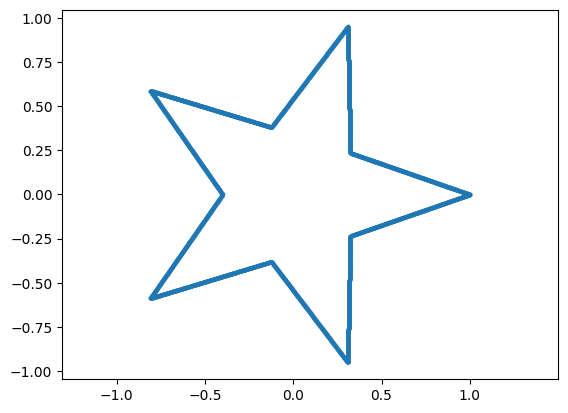

In [2]:
def generate_star(n_spikes=5, inner_radius=0.4, outer_radius=1.0, n_samples=5000, center=(0, 0)):
    points = []
    angle_step = np.pi / n_spikes

    vertices = []
    for i in range(2 * n_spikes):
        angle = i * angle_step
        radius = outer_radius if i % 2 == 0 else inner_radius
        x = radius * np.cos(angle) + center[0]
        y = radius * np.sin(angle) + center[1]
        vertices.append([x, y])

    vertices.append(vertices[0])
    vertices = np.array(vertices, dtype=np.float32)

    per_edge = max(2, n_samples // (len(vertices) - 1))
    for i in range(len(vertices) - 1):
        start_point = vertices[i]
        end_point = vertices[i + 1]
        for t in np.linspace(0, 1, per_edge, endpoint=False):
            point = (1 - t) * start_point + t * end_point
            points.append(point)

    return np.array(points, dtype=np.float32)

data = generate_star(n_samples=5000)
plt.scatter(data[:, 0], data[:, 1], s=3)
plt.axis("equal")
plt.show()

In [3]:
class VPConfig:
    def __init__(
        self,
        schedule="cosine",
        beta_min=0.1,
        beta_max=10.0,
        cosine_s=0.008,
        lr=3e-4,
        epochs=2500,
        batch_size=512,
        hidden_dim=256,
        time_dim=64,
        num_timesteps=1200,
        data_samples=5000,
        weighting="const",
        weight_clip=20.0,
        ema_decay=0.999,
        target_snr=0.08,
    ):
        self.schedule = schedule
        self.beta_min = beta_min
        self.beta_max = beta_max
        self.cosine_s = cosine_s
        self.lr = lr
        self.epochs = epochs
        self.batch_size = batch_size
        self.hidden_dim = hidden_dim
        self.time_dim = time_dim
        self.num_timesteps = num_timesteps
        self.data_samples = data_samples
        self.weighting = weighting
        self.weight_clip = weight_clip
        self.ema_decay = ema_decay
        self.target_snr = target_snr

In [4]:
class VPScoreModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.time_dim = config.time_dim

        self.time_mlp = nn.Sequential(
            nn.Linear(config.time_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
        )

        self.net = nn.Sequential(
            nn.Linear(config.hidden_dim + 2, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, config.hidden_dim),
            nn.SiLU(),
            nn.Linear(config.hidden_dim, 2),
        )

    def time_embedding(self, t):
        half = self.time_dim // 2
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(half, device=t.device, dtype=t.dtype) / max(half - 1, 1)
        )
        args = t * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=1)

    def forward(self, x, t):
        t_emb = self.time_mlp(self.time_embedding(t))
        return self.net(torch.cat([x, t_emb], dim=1))

In [5]:
def vp_terms(t, config):
    if config.schedule == "linear":
        beta = config.beta_min + t * (config.beta_max - config.beta_min)
        int_beta = config.beta_min * t + 0.5 * (config.beta_max - config.beta_min) * t ** 2
        alpha_bar = torch.exp(-int_beta)
    elif config.schedule == "cosine":
        s = config.cosine_s
        theta = (t + s) / (1.0 + s) * (math.pi / 2.0)
        theta0 = (s / (1.0 + s)) * (math.pi / 2.0)
        alpha_bar = (torch.cos(theta).clamp_min(1e-5) / math.cos(theta0)) ** 2
        beta = (math.pi / (1.0 + s)) * torch.tan(theta)
        beta = beta.clamp(min=1e-5, max=config.beta_max)
    else:
        raise ValueError

    alpha = torch.sqrt(alpha_bar.clamp_min(1e-5))
    sigma = torch.sqrt((1.0 - alpha_bar).clamp_min(1e-5))
    return beta, alpha, sigma

def loss_weight(t, alpha, sigma, config):
    eps = 1e-8
    if config.weighting == "const":
        w = torch.ones_like(t)
    elif config.weighting == "sigma2":
        w = sigma ** 2
    elif config.weighting == "snr":
        w = alpha ** 2 / (sigma ** 2 + eps)
    elif config.weighting == "beta":
        beta, _, _ = vp_terms(t, config)
        w = beta
    else:
        raise ValueError

    w = torch.clamp(w, max=config.weight_clip)
    w = w / (w.mean().detach() + eps)
    return w

def update_ema(ema_model, model, decay):
    with torch.no_grad():
        for ema_p, p in zip(ema_model.parameters(), model.parameters()):
            ema_p.data.mul_(decay).add_(p.data, alpha=1.0 - decay)

In [6]:
class VPTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

        star = generate_star(n_samples=config.data_samples)
        self.data = torch.tensor(star, dtype=torch.float32)
        self.dataset = TensorDataset(self.data)
        self.dataloader = DataLoader(self.dataset, batch_size=config.batch_size, shuffle=True)

        self.model = VPScoreModel(config).to(self.device)
        self.ema_model = copy.deepcopy(self.model).to(self.device)
        for p in self.ema_model.parameters():
            p.requires_grad = False

        self.optimizer = optim.Adam(self.model.parameters(), lr=config.lr)

    def train_epoch(self):
        self.model.train()
        total_loss = 0.0

        for (batch,) in self.dataloader:
            batch = batch.to(self.device)

            t = torch.rand(batch.shape[0], 1, device=self.device) * (1.0 - 2e-3) + 1e-3
            beta, alpha, sigma = vp_terms(t, self.config)

            noise = torch.randn_like(batch)
            x_t = alpha * batch + sigma * noise

            pred_noise = self.model(x_t, t)
            w = loss_weight(t, alpha, sigma, self.config)

            per_sample = ((pred_noise - noise) ** 2).mean(dim=1)
            loss = (w.squeeze(1) * per_sample).mean()

            self.optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
            self.optimizer.step()

            update_ema(self.ema_model, self.model, self.config.ema_decay)

            total_loss += loss.item() * batch.shape[0]

        return total_loss / len(self.data)

    def run(self, verbose=True):
        hist = []
        for epoch in range(self.config.epochs):
            loss = self.train_epoch()
            hist.append(loss)
            if verbose and epoch % 200 == 0:
                print(f"[{self.config.schedule}, {self.config.weighting}] epoch {epoch:4d} loss {loss:.6f}")
        return hist

In [7]:
def sample_vp_sde(model, config, num_samples=1000):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(num_samples, 2, device=device)
    h = 1.0 / config.num_timesteps

    with torch.no_grad():
        for i in range(config.num_timesteps):
            t = 1.0 - i * h
            t = max(t, 1e-3)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta, _, sigma = vp_terms(t_tensor, config)
            pred_noise = model(x, t_tensor)
            score = -pred_noise / sigma.clamp_min(1e-4)

            drift = (0.5 * beta * x + beta * score) * h
            diffusion = torch.sqrt(beta * h) * torch.randn_like(x)

            if i == config.num_timesteps - 1:
                diffusion = torch.zeros_like(x)

            x = x + drift + diffusion

    return x.cpu().numpy()

def sample_vp_pc(model, config, num_samples=1000, corrector_steps=1):
    device = next(model.parameters()).device
    model.eval()

    x = torch.randn(num_samples, 2, device=device)
    h = 1.0 / config.num_timesteps

    with torch.no_grad():
        for i in range(config.num_timesteps):
            t = 1.0 - i * h
            t = max(t, 1e-3)
            t_tensor = torch.full((num_samples, 1), t, device=device)

            beta, _, sigma = vp_terms(t_tensor, config)
            pred_noise = model(x, t_tensor)
            score = -pred_noise / sigma.clamp_min(1e-4)

            for _ in range(corrector_steps):
                noise = torch.randn_like(x)
                grad_norm = torch.sqrt(torch.mean(score ** 2, dim=1, keepdim=True) + 1e-6)
                noise_norm = torch.sqrt(torch.mean(noise ** 2, dim=1, keepdim=True) + 1e-6)
                step_size = (config.target_snr * noise_norm / (grad_norm + 1e-6)) ** 2 * 2.0
                step_size = torch.clamp(step_size, max=0.15)
                x = x + step_size * score + torch.sqrt(2.0 * step_size) * noise
                pred_noise = model(x, t_tensor)
                score = -pred_noise / sigma.clamp_min(1e-4)

            drift = (0.5 * beta * x + beta * score) * h
            diffusion = torch.sqrt(beta * h) * torch.randn_like(x)

            if i == config.num_timesteps - 1:
                diffusion = torch.zeros_like(x)

            x = x + drift + diffusion

    return x.cpu().numpy()

In [8]:
def make_config(schedule="cosine", weighting="const", epochs=1200):
    return VPConfig(
        schedule=schedule,
        weighting=weighting,
        epochs=epochs,
        beta_min=0.1,
        beta_max=10.0,
        lr=3e-4,
        batch_size=512,
        hidden_dim=256,
        time_dim=64,
        num_timesteps=1200,
        data_samples=5000,
        weight_clip=20.0,
        ema_decay=0.999,
        target_snr=0.08,
    )

def run_experiment(schedule="cosine", weighting="const", epochs=1200, use_pc=False):
    config = make_config(schedule=schedule, weighting=weighting, epochs=epochs)
    trainer = VPTrainer(config)
    history = trainer.run(verbose=True)
    sampler = sample_vp_pc if use_pc else sample_vp_sde
    samples = sampler(trainer.ema_model, config, num_samples=1000)
    return config, trainer, history, samples

In [11]:
linear_const = run_experiment(schedule="linear", weighting="const", epochs=3000, use_pc=False)

[linear, const] epoch    0 loss 0.969639
[linear, const] epoch  200 loss 0.238657
[linear, const] epoch  400 loss 0.240381
[linear, const] epoch  600 loss 0.246071
[linear, const] epoch  800 loss 0.247465
[linear, const] epoch 1000 loss 0.250930
[linear, const] epoch 1200 loss 0.242754
[linear, const] epoch 1400 loss 0.243149
[linear, const] epoch 1600 loss 0.235708
[linear, const] epoch 1800 loss 0.233742
[linear, const] epoch 2000 loss 0.252034
[linear, const] epoch 2200 loss 0.237583
[linear, const] epoch 2400 loss 0.243149
[linear, const] epoch 2600 loss 0.237172
[linear, const] epoch 2800 loss 0.251984


In [12]:
cosine_const = run_experiment(schedule="cosine", weighting="const", epochs=3000, use_pc=False)

[cosine, const] epoch    0 loss 0.971853
[cosine, const] epoch  200 loss 0.333275
[cosine, const] epoch  400 loss 0.328720
[cosine, const] epoch  600 loss 0.332190
[cosine, const] epoch  800 loss 0.330033
[cosine, const] epoch 1000 loss 0.336069
[cosine, const] epoch 1200 loss 0.329545
[cosine, const] epoch 1400 loss 0.326006
[cosine, const] epoch 1600 loss 0.318853
[cosine, const] epoch 1800 loss 0.333599
[cosine, const] epoch 2000 loss 0.331534
[cosine, const] epoch 2200 loss 0.329912
[cosine, const] epoch 2400 loss 0.312255
[cosine, const] epoch 2600 loss 0.294581
[cosine, const] epoch 2800 loss 0.289916


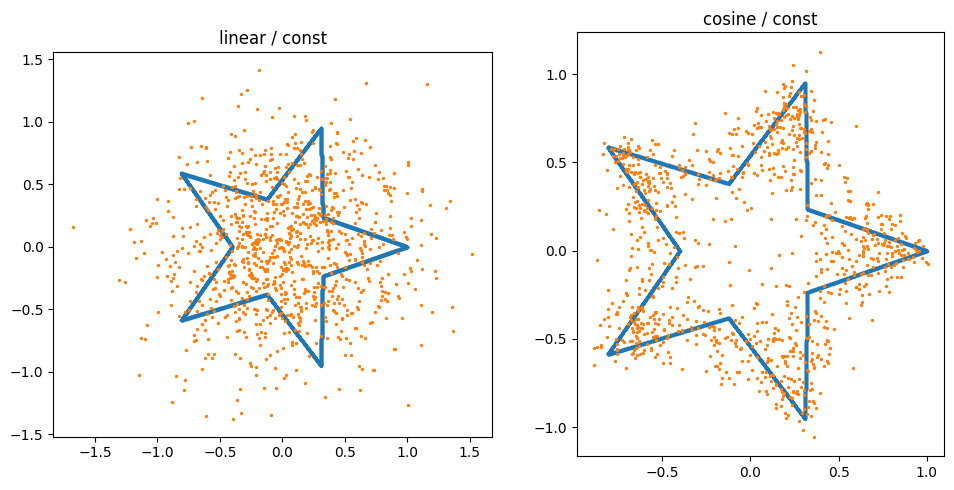

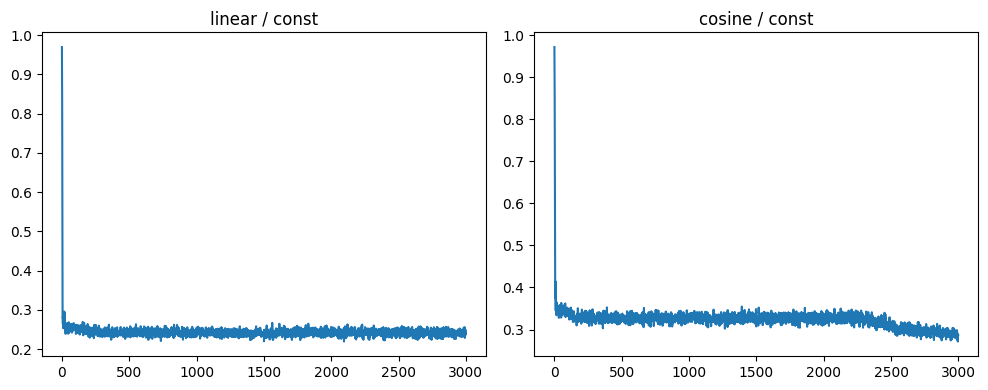

In [13]:
real_data = linear_const[1].data.cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, result, title in zip(axes, [linear_const, cosine_const], ["linear / const", "cosine / const"]):
    samples = result[3]
    ax.scatter(real_data[:, 0], real_data[:, 1], s=2)
    ax.scatter(samples[:, 0], samples[:, 1], s=2)
    ax.set_title(title)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(linear_const[2])
axes[0].set_title("linear / const")
axes[1].plot(cosine_const[2])
axes[1].set_title("cosine / const")
plt.tight_layout()
plt.show()

При базовом взвешивании лосса (const) оба расписания справляются с задачей, однако cosine показывает более стабильные результаты генерации.

Линейное расписание слишком агрессивно наращивает дисперсию шума на поздних этапах диффузии (при t→1). Это приводит к тому, что сигнал разрушается слишком быстро. Косинусовое расписание распределяет шум более плавно, оставляя модели больше шагов для изучения промежуточных масштабов и тонких деталей структуры.

По графикам наблюдается, что cosine более четко передал структуру при генерации.

In [14]:
weightings = ["snr", "beta", "sigma2"]
weight_runs = [run_experiment(schedule="cosine", weighting=w, epochs=3000, use_pc=False) for w in weightings]

[cosine, snr] epoch    0 loss 1.000614
[cosine, snr] epoch  200 loss 0.796084
[cosine, snr] epoch  400 loss 0.797756
[cosine, snr] epoch  600 loss 0.817368
[cosine, snr] epoch  800 loss 0.801653
[cosine, snr] epoch 1000 loss 0.701607
[cosine, snr] epoch 1200 loss 0.702925
[cosine, snr] epoch 1400 loss 0.656633
[cosine, snr] epoch 1600 loss 0.608727
[cosine, snr] epoch 1800 loss 0.641591
[cosine, snr] epoch 2000 loss 0.614207
[cosine, snr] epoch 2200 loss 0.619228
[cosine, snr] epoch 2400 loss 0.617848
[cosine, snr] epoch 2600 loss 0.613234
[cosine, snr] epoch 2800 loss 0.638114
[cosine, beta] epoch    0 loss 0.961771
[cosine, beta] epoch  200 loss 0.102262
[cosine, beta] epoch  400 loss 0.101620
[cosine, beta] epoch  600 loss 0.105010
[cosine, beta] epoch  800 loss 0.101625
[cosine, beta] epoch 1000 loss 0.106874
[cosine, beta] epoch 1200 loss 0.109103
[cosine, beta] epoch 1400 loss 0.104399
[cosine, beta] epoch 1600 loss 0.104013
[cosine, beta] epoch 1800 loss 0.103105
[cosine, beta] 

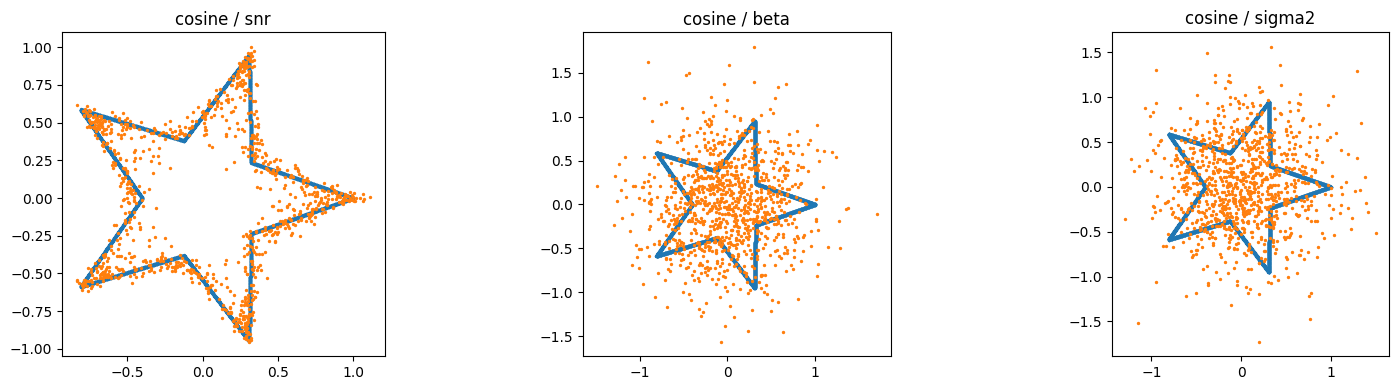

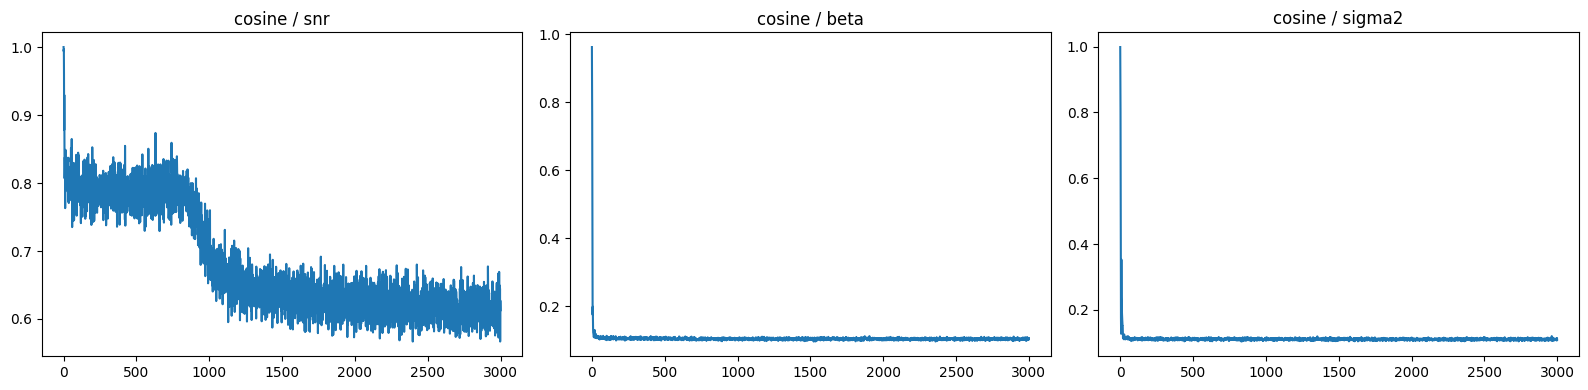

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, result, w in zip(axes, weight_runs, weightings):
    samples = result[3]
    ax.scatter(real_data[:, 0], real_data[:, 1], s=2)
    ax.scatter(samples[:, 0], samples[:, 1], s=2)
    ax.set_title(f"cosine / {w}")
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, result, w in zip(axes, weight_runs, weightings):
    ax.plot(result[2])
    ax.set_title(f"cosine / {w}")
plt.tight_layout()
plt.show()

Анализ графиков с различными функциями весов показал радикальное влияние на качество итогового распределения:

-    const: Дает базовый, приемлемый результат. Контуры звезды угадываются, но дисперсия точек вокруг лучей остается высокой. Модель уделяет одинаковое внимание всем уровням шума, что не является оптимальным.

-    SNR: Лучший вариант. Взвешивание по Signal-to-Noise Ratio логично фокусирует штраф на тех промежутках времени, где модель реально может выучить геометрию данных (средние уровни шума). Генерация получается наиболее четкой, сохраняются острые углы звезды, количество фонового шума минимально.

-    beta и sigma2: Привели к полному коллапсу генерации. На графиках видно, что модель стягивает все точки в бесформенное облако в центре координат. График лосса для этих весов моментально падает почти в ноль - это означает, что веса слишком сильно штрафуют предсказания на экстремальных уровнях шума (где предсказать исходную структуру невозможно), игнорируя этапы формирования макроструктуры. Модель находит локальный минимум и перестает учиться.

**Итог**

Наилучшей конфигурацией для задачи VP-SDE оказалась связка косинусового расписания и SNR-взвешивания.